### Аналіз Wine Quality Dataset

Wine Quality Dataset містить дані про фізико-хімічні характеристики червоного вина та оцінку його якості. Кожен рядок описує один зразок вина через показники кислотності, цукру, хлоридів, діоксиду сірки, густини, pH, сульфатів, алкоголю та підсумкову якість.

#### Практична задача

За фізико-хімічними характеристиками вина передбачити його якість.

#### Dataset

`/Users/dmitrostefan/Edu/python-ai-2026/data/WineQT.csv`

#### Опис колонок

| Колонка | Що означає | Тип даних | Чи корисна для ML |
|---|---|---|---|
| `fixed acidity` | фіксована кислотність вина | число | так, це вхідна ознака |
| `volatile acidity` | летка кислотність вина | число | так, це вхідна ознака |
| `citric acid` | кількість лимонної кислоти | число | так, це вхідна ознака |
| `residual sugar` | залишковий цукор після ферментації | число | так, це вхідна ознака |
| `chlorides` | кількість хлоридів | число | так, це вхідна ознака |
| `free sulfur dioxide` | вільний діоксид сірки | число | так, це вхідна ознака |
| `total sulfur dioxide` | загальний діоксид сірки | число | так, це вхідна ознака |
| `density` | густина вина | число | так, це вхідна ознака |
| `pH` | рівень кислотності за шкалою pH | число | так, це вхідна ознака |
| `sulphates` | кількість сульфатів | число | так, це вхідна ознака |
| `alcohol` | вміст алкоголю | число | так, це вхідна ознака |
| `quality` | оцінка якості вина | число | так, але як цільова ознака |
| `Id` | ідентифікатор зразка | число | ні, це службова колонка |

#### Завантаження даних

Завантажимо Wine Quality Dataset через `read_csv`, видалимо службову колонку `Id` і подивимося на перші рядки.

In [2]:
import pandas as pd

wine_df = pd.read_csv('../../data/WineQT.csv')
wine_df = wine_df.drop(columns=['Id'])
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<Axes: >

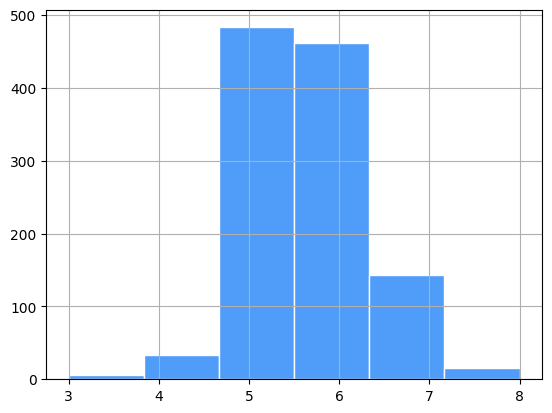

In [3]:
wine_df['quality'].hist(bins=6,
                        color='#4f9cf9',
                        edgecolor='white')

#### Описова статистика для числових колонок

Порахуємо `mean`, `median`, `mode`, `variance` і `std` для цільової змінної `quality` та кількох ознак: `volatile acidity`, `citric acid`, `residual sugar`, `sulphates`, `alcohol`.

In [4]:
selected_columns = [
    'quality',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'sulphates',
    'alcohol',
]

statistics_df = pd.DataFrame({
    'mean': wine_df[selected_columns].mean(),
    'median': wine_df[selected_columns].median(),
    'mode': wine_df[selected_columns].mode().iloc[0],
    'variance': wine_df[selected_columns].var(),
    'std': wine_df[selected_columns].std(),
})

statistics_df.round(3)

,mean,median,mode,variance,std
quality,5.657,6.00,5.0,0.649,0.806
volatile acidity,0.531,0.52,0.5,0.032,0.180
citric acid,0.268,0.25,0.0,0.039,0.197
residual sugar,2.532,2.20,2.0,1.839,1.356
sulphates,0.658,0.62,0.6,0.029,0.170
alcohol,10.442,10.20,9.5,1.171,1.082


#### Кореляція між парами ознак

Порахуємо кореляцію для кількох пар. Мінімум дві пари включають цільову змінну `quality`.

In [5]:
feature_pairs = [
    ('alcohol', 'quality'),
    ('volatile acidity', 'quality'),
    ('sulphates', 'quality'),
    ('fixed acidity', 'citric acid'),
]

correlations_df = pd.DataFrame(
    [
        {
            'feature_1': feature_1,
            'feature_2': feature_2,
            'correlation': wine_df[feature_1].corr(wine_df[feature_2]),
        }
        for feature_1, feature_2 in feature_pairs
    ]
)

correlations_df.round(3)

,feature_1,feature_2,correlation
0,alcohol,quality,0.485
1,volatile acidity,quality,-0.407
2,sulphates,quality,0.258
3,fixed acidity,citric acid,0.673


#### Інтерпретація кореляцій

`alcohol` має помітну позитивну кореляцію з `quality`: вина з вищим вмістом алкоголю зазвичай отримують вищу оцінку якості. Це корисний сигнал для пояснення або прогнозування якості.

`volatile acidity` має негативну кореляцію з `quality`: більша летка кислотність частіше пов'язана з нижчою оцінкою. Для вина це логічно, бо надмірна летка кислотність може погіршувати смак.

`sulphates` має позитивну кореляцію з `quality`, але зв'язок слабший за `alcohol`. Ця ознака може бути корисною разом з іншими фізико-хімічними характеристиками.

`fixed acidity` і `citric acid` мають позитивну кореляцію між собою, бо обидві ознаки описують кислотний профіль вина.

#### Колонка з помітною різницею між середнім і медіаною

Перевіримо різницю між середнім і медіаною для вибраних колонок.

In [6]:
input_columns = selected_columns[1:]

mean_median_difference_df = pd.DataFrame({
    'mean': wine_df[input_columns].mean(),
    'median': wine_df[input_columns].median(),
})

mean_median_difference_df['absolute_difference'] = (
    mean_median_difference_df['mean'] - mean_median_difference_df['median']
).abs()

mean_median_difference_df.sort_values('absolute_difference', ascending=False).round(3)

,mean,median,absolute_difference
residual sugar,2.532,2.20,0.332
alcohol,10.442,10.20,0.242
sulphates,0.658,0.62,0.038
citric acid,0.268,0.25,0.018
volatile acidity,0.531,0.52,0.011


У колонці `residual sugar` середнє значення помітно більше за медіану серед вибраних вхідних ознак. Це може означати, що розподіл має правий хвіст: більшість зразків має відносно помірний рівень залишкового цукру, але є вина з вищим рівнем цукру, які підтягують середнє вгору. У такій ситуації медіана краще описує типовий зразок, ніж середнє.

#### Короткий підсумок

Найкраще якість вина в цьому датасеті, на мою думку, допомагає пояснити `alcohol`, бо ця ознака має найпомітнішу позитивну кореляцію з `quality` серед вибраних колонок. Також корисними виглядають `volatile acidity` і `sulphates`, але якість вина варто прогнозувати за комбінацією ознак, а не за однією колонкою.